load raster, look into, clip, count, and plot

In [9]:
from pathlib import Path
import rioxarray as rxr
import geopandas as gpd

ROOT = Path.cwd().parent
fccl = rxr.open_rasterio(ROOT / "data/raw/FCCL_DE_P1M.tif")
aoi = gpd.read_file(ROOT / "data/raw/aoi.gpkg")

print(fccl.rio.crs, fccl.rio.nodata, fccl.shape)
print(aoi.crs, aoi.total_bounds)

EPSG:3035 255 (1, 88989, 66822)
EPSG:4326 [10.3635 51.6196 10.7794 51.8868]


these next cells will do the following:
1. open the raster. the fccl raster covers all of Germany at 10m. so, thats roughly 5.9 billion pixels -> 6gb. the chunks will open it lazily through dask. nothing is loaded until actual values are asked for
2. when i was looking at the polygon data in QGIS, my AOI was in EPSG:4326 degrees. This data uses EPSG:3035 laea europe (meters).
**`clip_box` before `clip`.** `clip_box` does a windowed read — it goes to
   the file and pulls only the blocks covering our bounding box. `clip` masks
   to the exact polygon, but builds that mask across the raster's full extent
   first. Running `clip` alone on a national raster will exhaust memory.
General rule for this stack: **subset by bounds, then mask by geometry, then
compute.**
3. see what each pixel means. we can actually check through the README.md given with the forest canopy loss raster. so:
- `255` — not forest. The product is clipped to the Thünen stocked-area mask
  2018, so anything outside mapped forest is nodata.
- `0` — forest, no canopy loss detected. This is our intact control population.
- `1` to `98` — the month canopy loss was recorded, counting from
  September 2017 (1) to October 2025 (98).

We exclude 255 before counting, since summing nodata across millions of
non-forest pixels would be meaningless. `np.unique(..., return_counts=True)`
then gives the pixel count per month code, which converts directly to area:
one pixel is 10 × 10 m, so 100 pixels = 1 hectare.

In [5]:
fccl = rxr.open_rasterio(
    ROOT / "data/raw/FCCL_DE_P1M.tif",
    chunks={"x": 2048, "y": 2048},
)

In [7]:
aoi_3035 = aoi.to_crs(3035)
minx, miny, maxx, maxy = aoi_3035.total_bounds

clip = fccl.rio.clip_box(minx, miny, maxx, maxy)
clip = clip.rio.clip(aoi_3035.geometry, aoi_3035.crs)
clip = clip.compute()
print(clip.shape, clip.nbytes / 1e6, "MB")

(1, 2995, 2895) 8.670525 MB


In [8]:
import numpy as np

vals = clip.values[0]
u, c = np.unique(vals[vals != 255], return_counts=True)
print("n classes:", len(u), "min:", u.min(), "max:", u.max())
print(list(zip(u.tolist(), c.tolist())))

n classes: 99 min: 0 max: 98
[(0, 3711796), (1, 777), (2, 14771), (3, 120), (4, 9), (5, 2060), (6, 6481), (7, 32638), (8, 26559), (9, 18621), (10, 4852), (11, 6269), (12, 19891), (13, 38080), (14, 21500), (15, 14648), (16, 15499), (17, 28676), (18, 21900), (19, 22658), (20, 55457), (21, 4218), (22, 24884), (23, 5622), (24, 87396), (25, 88424), (26, 55502), (27, 19775), (28, 88816), (29, 10038), (30, 2885), (31, 184050), (32, 32955), (33, 21347), (34, 46144), (35, 65409), (36, 116748), (37, 236109), (38, 16218), (39, 160158), (40, 5229), (41, 230246), (42, 57010), (43, 24236), (44, 36866), (45, 39044), (46, 12049), (47, 40084), (48, 104805), (49, 140758), (50, 31178), (51, 46444), (52, 22144), (53, 33041), (54, 334726), (55, 88593), (56, 22288), (57, 23537), (58, 34727), (59, 30916), (60, 64964), (61, 32636), (62, 69151), (63, 19913), (64, 17204), (65, 40539), (66, 15706), (67, 22737), (68, 64500), (69, 18319), (70, 4324), (71, 6007), (72, 18217), (73, 3845), (74, 1241), (75, 3219), (76

Essentially this printed means:
Disturbance by year:
Year	Hectares
2017	157
2018	2,071
2019	5,033
2020	8,973
2021	7,849
2022	7,717
2023	2,115
2024	838
2025	398

It's important to note that Feb 2022 had 3,347 hectares disturbed. this was the result of the Ylenia/Zeynep/Antonia storm series that hit Germany between 16 and 21 of February 2022. This will be useful in future latency benchmarking becuase we have the actual dates of this storm.

Plot per year

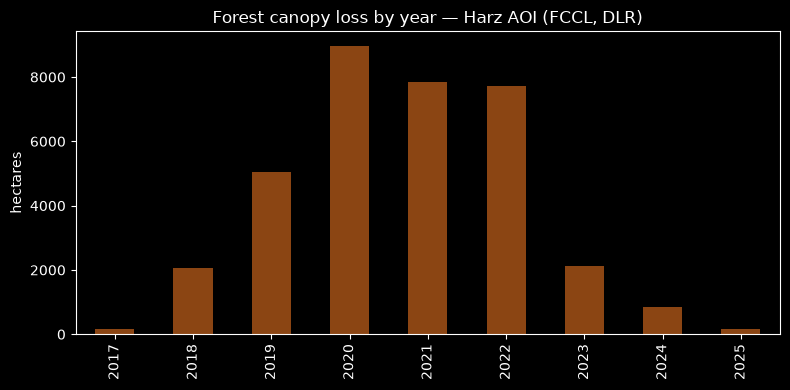

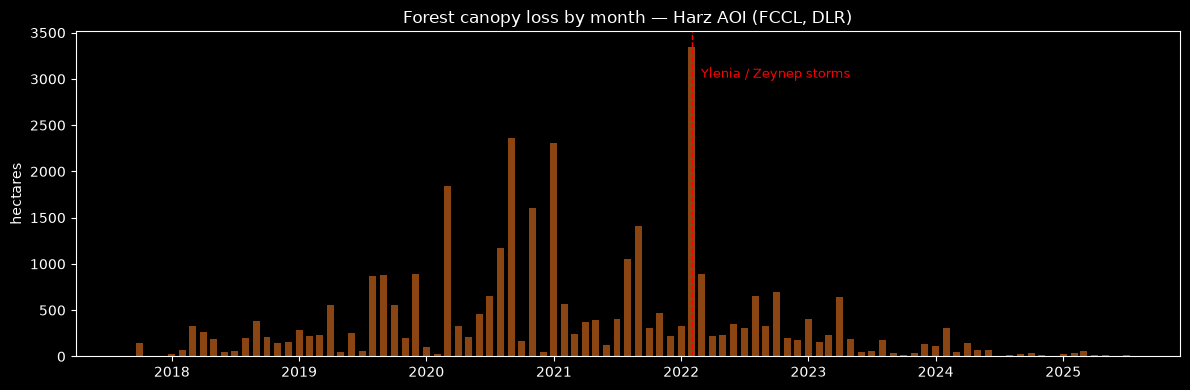

Total disturbed: 34,902 ha
Study period 2019–2022: 29,572 ha
date
2017     156.77
2018    2070.98
2019    5033.28
2020    8972.90
2021    7848.64
2022    7716.96
2023    2115.12
2024     837.56
2025     149.91


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def code_to_date(m):
    """FCCL month code -> first day of that month. 1 = Sept 2017, 98 = Oct 2025."""
    t = 8 + (int(m) - 1)
    return pd.Timestamp(2017 + t // 12, t % 12 + 1, 1)

#Keeps only tje detected losses. we need to drop nodata (255), intact forest (0)
#as well as any of the final months DLR flags as low-confidence or likely overestimated
mask = (vals > 0) & (vals != 255) & (vals < 96)
u, c = np.unique(vals[mask], return_counts=True)

#10m pixels -> 100 px per hectare
df = pd.DataFrame({"date": [code_to_date(m) for m in u], "ha": c * 0.01})
df = df.set_index("date").sort_index()

#annual
annual = df["ha"].resample("YE").sum()
annual.index = annual.index.year

fig, ax = plt.subplots(figsize=(8, 4))
annual.plot.bar(ax=ax, color="#8B4513")
ax.set_title("Forest canopy loss by year — Harz AOI (FCCL, DLR)")
ax.set_ylabel("hectares")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

#monthly plots
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(df.index, df["ha"], width=20, color="#8B4513")
ax.set_title("Forest canopy loss by month — Harz AOI (FCCL, DLR)")
ax.set_ylabel("hectares")
ax.axvline(pd.Timestamp("2022-02-01"), color="red", ls="--", lw=1)
ax.text(pd.Timestamp("2022-02-15"), df["ha"].max() * 0.9,
        " Ylenia / Zeynep storms", color="red", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Total disturbed: {df['ha'].sum():,.0f} ha")
print(f"Study period 2019–2022: {df.loc['2019':'2022', 'ha'].sum():,.0f} ha")
print(annual.to_string())